# Figure 3: Bound Summary

Translation of `Figure03_boundSummary.m`

## What this notebook does

Characterizes how participants' decision bounds vary with Decision Time (DT) and across trials in the online (OL) task.

Five panels (all using block 2, lowest SNR):

- **Panel A**: Individual trial bounds vs. DT for one example participant.
- **Panel B**: Z-scored bound vs. DT for all 60 participants (shows group-level DT dependence).
- **Panel C**: Histogram of linear-regression slopes (bound ~ DT) per participant.
- **Panel D**: Histogram of trial-to-trial bound change slopes (Δbound ~ current bound) per participant.
- **Panel E**: Mean ± SEM bound height vs. mean ± SEM DT per participant (x and y errorbars).

**Data**: Online (OL) task, block 2, lowest SNR condition.

## Imports

Imports standard scientific Python libraries plus `get_data_table` and `get_bound_summary` from the pigeon package. No data loading or filtering here.

## Load data

Loads all OL (online) trials via `get_data_table(task_type='OL')`. Internal processing:
- Reads all CSV files from `DATA_DIR/Pigeon_OL/prolificcsvs/`
- Computes `bound`, `DT`, `RT` for each trial from step sequences
- Marks wall-hit trials (|position| ≥ 0.75) in the `wall_hit` column
- Applies bias correction if `boundBiasCorrection.mat` is present
- Combines blocks 4–6 into 1–3

All subjects and blocks retained at this stage.

## Compute bound summary

Calls `get_bound_summary(data_table_ol)` which applies the following filters internally (via `get_good_trial_array`):

**Data included**: Trials with `DT ≥ 2`, `trial_number ≥ 10`, `bound` finite and non-zero, `correct ≥ 0`, `wall_hit = False`, and `rt_below_cutoff = False` (RT meets the per-block/SNR reliability threshold from `get_bounds`).

**Data excluded**: Trials with `DT < 2` (too short), first 9 trials per block (warm-up), wall-hit trials, trials with missing bounds.

Output shape: `(n_subjects, n_blocks, n_snrs, n_rt_bins, 3)` where the last dimension is `[mean_abs_bound, std_abs_bound, n_trials]`.

## Select analysis parameters

Restricts analysis to block 2 (`BLOCK=2`) and the lowest SNR condition (`min_snr`).
Constructs the boolean filter `lg` used in all downstream panels.

**Data included**: Trials where `bound` is finite, `|SNR| ≈ min_snr`,
`block_index == BLOCK`, `DT ≥ 2`, `trial_number ≥ 10`, and `wall_hit = False` —
matching the filters applied internally by `get_bound_summary`. Using the same
filters ensures that the per-trial panels (A–E) draw from the same population as
the bound-summary statistics.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats

from pigeon.data import get_data_table
from pigeon.stats import get_bound_summary
from pigeon.pathDefaults import FIGURES_DIR

In [2]:
data_table_ol = get_data_table(task_type='OL')

  1: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_14h39.24.096.csv
  2: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_15h37.48.260.csv
  3: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h34.46.761.csv
  4: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h35.25.285.csv
  5: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.33.669.csv
  6: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.41.364.csv
  7: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pigeon/Data/Pigeon_OL/prolificcsvs/PigeonTask_2022-11-21_16h36.49.086.csv
  8: /Users/jigold/GoldWorks/Mirror_jigold/Manuscripts/2023_Pi

In [3]:
# bound_summary shape: (n_subjects, n_blocks, n_snrs, n_rt_bins, 3)
# Last dim: [mean_abs_bound, std_abs_bound, n_trials]
bound_summary = get_bound_summary(data_table_ol)
print('bound_summary shape:', bound_summary.shape)

bound_summary shape: (60, 3, 2, 10, 3)


In [ ]:
BLOCK = 2  # representative block (1-indexed)

n_subjects, n_blocks, n_snrs, n_rt_bins, _ = bound_summary.shape

# Unique absolute SNR values present in the dataset
abs_snr = np.abs(data_table_ol['snr'].to_numpy())
snrs = np.sort(np.unique(abs_snr[np.isfinite(abs_snr)]))
min_snr = snrs[0]

# Quality filter applied to raw data_table_ol — matches get_good_trial_array criteria
# used internally by get_bound_summary so all panels draw from the same trial set.
lg = (
    data_table_ol['bound'].notna() &
    pd.Series(np.isclose(abs_snr, min_snr), index=data_table_ol.index) &
    (data_table_ol['block_index'] == BLOCK) &
    (data_table_ol['DT'] >= 2) &
    (data_table_ol['trial_number'] >= 10) &
    (data_table_ol['wall_hit'] == False)
)

subjects = np.sort(data_table_ol['subject_index'].dropna().unique())

## Compute per-panel statistics

Computes all inputs needed for the five figure panels and prints key statistics.

- **Panel A**: Example session — mean |bound| per DT bin for subject `EXAMPLE_SESSION`.
- **Panel B**: Z-scored bound vs. DT per subject; Spearman correlation of the group mean with DT.
- **Panel C**: Linear-regression slope of |bound| ~ DT per subject (DT ≥ 2); Wilcoxon test vs. 0.
- **Panel D**: Linear-regression slope of Δ|bound| ~ current |bound| per subject; Wilcoxon tests vs. −1 (regression to mean) and vs. 0.
- **Panel E**: Per-subject mean ± SEM of |bound| and DT; Spearman correlation between them.

In [ ]:
EXAMPLE_SESSION = 16
dt_vals = np.arange(1, n_rt_bins + 1)

# Panel A: example session bounds vs DT
ls_ex = lg & (data_table_ol['subject_index'] == EXAMPLE_SESSION)
ex = data_table_ol[ls_ex].copy()
ex_mean_per_dt = np.array([np.nanmean(np.abs(ex.loc[ex['DT'] == dt, 'bound']))
                            for dt in dt_vals])
ex_n_per_dt    = np.array([ex['DT'].eq(dt).sum() for dt in dt_vals])

# Panel B: z-scored bound vs DT for all subjects
subj_means = np.full((len(subjects), n_rt_bins), np.nan)
for si, subj in enumerate(subjects):
    ls  = lg & (data_table_ol['subject_index'] == subj)
    sub = data_table_ol[ls].copy()
    if len(sub) < 5:
        continue
    ab = np.abs(sub['bound'].to_numpy(dtype=float))
    mu, sd = np.nanmean(ab), np.nanstd(ab)
    if sd == 0:
        continue
    z = (ab - mu) / sd
    for ri, dt in enumerate(dt_vals):
        vals = z[sub['DT'].to_numpy() == dt]
        if len(vals) > 0:
            subj_means[si, ri] = np.nanmean(vals)
group_mean = np.nanmean(subj_means, axis=0)
valid_gm   = np.isfinite(group_mean)
r_b, p_b   = scipy.stats.spearmanr(dt_vals[valid_gm], group_mean[valid_gm])
print(f'Panel B: group mean z-bound Spearman r = {r_b:.2f}, p = {p_b:.4f}')

# Panel C: |bound| vs DT regression slopes (lg already ensures DT >= 2)
slopes_c = []
for subj in subjects:
    ls  = lg & (data_table_ol['subject_index'] == subj)
    sub = data_table_ol[ls]
    if len(sub) < 5:
        continue
    dts = sub['DT'].to_numpy(dtype=float)
    ab  = np.abs(sub['bound'].to_numpy(dtype=float))
    ok  = np.isfinite(dts) & np.isfinite(ab)
    if ok.sum() < 3:
        continue
    slope, *_ = scipy.stats.linregress(dts[ok], ab[ok])
    slopes_c.append(slope)
slopes_c = np.array(slopes_c)
med_c    = np.nanmedian(slopes_c)
bins_c   = np.arange(-0.04, 0.04 + 0.008, 0.008)
_, p_c   = scipy.stats.wilcoxon(slopes_c)
print(f'Panel C: median slope = {med_c:.4f}, Wilcoxon p = {p_c:.4f}')

# Panel D: Δbound vs current bound regression slopes
slopes_d = []
for subj in subjects:
    ls  = lg & (data_table_ol['subject_index'] == subj)
    sub = data_table_ol[ls].sort_values('trial_number')
    if len(sub) < 5:
        continue
    ab    = np.abs(sub['bound'].to_numpy(dtype=float))
    curr  = ab[1:]
    delta = curr - ab[:-1]
    ok    = np.isfinite(curr) & np.isfinite(delta)
    if ok.sum() < 3:
        continue
    slope, *_ = scipy.stats.linregress(curr[ok], delta[ok])
    slopes_d.append(slope)
slopes_d  = np.array(slopes_d)
med_d     = np.nanmedian(slopes_d)
bins_d    = np.arange(0, 2 + 0.15, 0.15)
_, p_d_m1 = scipy.stats.wilcoxon(slopes_d + 1)
_, p_d_0  = scipy.stats.wilcoxon(slopes_d)
print(f'Panel D: median slope = {med_d:.4f}, Wilcoxon vs -1 p = {p_d_m1:.4f}, vs 0 p = {p_d_0:.4f}')

# Panel E: mean ± SEM bound and DT per subject
mean_bound = np.full(len(subjects), np.nan)
sem_bound  = np.full(len(subjects), np.nan)
mean_dt    = np.full(len(subjects), np.nan)
sem_dt     = np.full(len(subjects), np.nan)
for si, subj in enumerate(subjects):
    ls  = lg & (data_table_ol['subject_index'] == subj)
    sub = data_table_ol[ls]
    if len(sub) < 5:
        continue
    ab  = np.abs(sub['bound'].to_numpy(dtype=float))
    dts = sub['DT'].to_numpy(dtype=float)
    n   = len(sub)
    mean_bound[si] = np.nanmean(ab)
    sem_bound[si]  = np.nanstd(ab) / np.sqrt(n)
    mean_dt[si]    = np.nanmean(dts)
    sem_dt[si]     = np.nanstd(dts) / np.sqrt(n)
valid  = np.isfinite(mean_bound) & np.isfinite(mean_dt)
r_e, p_e = scipy.stats.spearmanr(mean_dt[valid], mean_bound[valid])
print(f'Panel E: mean bound vs mean DT Spearman r = {r_e:.2f}, p = {p_e:.4f}')

## Figure

Publication layout matching MATLAB's `getPLOT_axes` call:

```matlab
getPLOT_axes(3, 8.5, [4,4,2,4], {1,1,2,1}, 1.3, 1.5, [], 'Pigeons', true)
```

- **Width**: 8.5 cm; **Row heights**: [4, 4, 2, 4] cm; vertical separation 1.3 cm; horizontal 1.5 cm
- Panels A, B, E span the full width; panels C and D share row 3 as equal halves
- **Font size**: 12 pt
- Saves to `Figure03.pdf`.

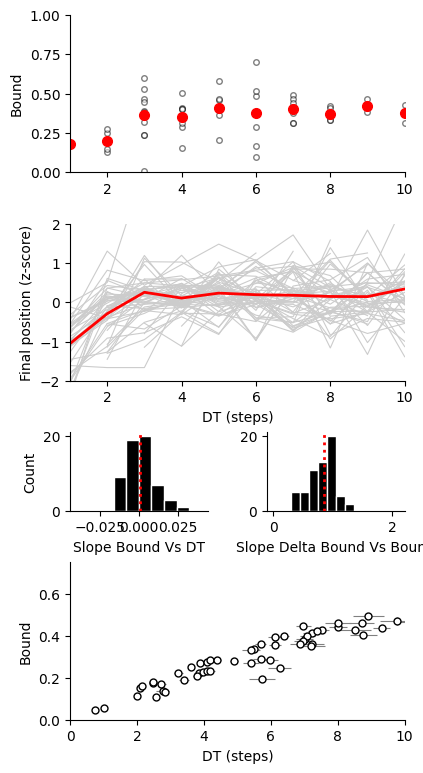

Saved /Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Projects/2025_Pigeon/Figures/Figure03_formatted.pdf


In [ ]:
import matplotlib.gridspec as gridspec

CM  = 1 / 2.54
WID = 8.5
HTS = [4.0, 4.0, 2.0, 4.0]
PSH = 1.3
PSW = 1.5
FS  = 12

fig_h       = sum(HTS) + PSH * (len(HTS) - 1)
panel_w     = (WID - PSW) / 2
hspace_frac = PSH / np.mean(HTS)
wspace_frac = PSW / panel_w

fig = plt.figure(figsize=(WID * CM, fig_h * CM))
gs = gridspec.GridSpec(4, 2, figure=fig,
                       height_ratios=HTS,
                       hspace=hspace_frac, wspace=wspace_frac,
                       left=0, right=1, bottom=0, top=1)

ax_A = fig.add_subplot(gs[0, :])
ax_B = fig.add_subplot(gs[1, :])
ax_C = fig.add_subplot(gs[2, 0])
ax_D = fig.add_subplot(gs[2, 1])
ax_E = fig.add_subplot(gs[3, :])

plt.rcParams.update({'font.size': FS, 'axes.labelsize': FS, 'axes.titlesize': FS})

gr = (0.8, 0.8, 0.8)

# Panel A: Example session — individual bounds vs. DT
ax_A.plot(ex['DT'], np.abs(ex['bound']), 'o', color='k',
          markerfacecolor='w', markersize=4, alpha=0.5)
ax_A.plot(dt_vals[ex_n_per_dt > 0], ex_mean_per_dt[ex_n_per_dt > 0],
          'ro', markerfacecolor='r', markersize=7)
ax_A.set_xlim(1, 10)
ax_A.set_ylim(0, 1)
ax_A.set_ylabel('Bound')

# Panel B: Z-scored bound vs. DT — all subjects
ax_B.plot(dt_vals, subj_means.T, '-', color=gr, linewidth=0.8)
ax_B.plot(dt_vals, np.nanmean(subj_means, axis=0), 'r-', linewidth=2)
ax_B.set_xlim(1, 10)
ax_B.set_ylim(-2, 2)
ax_B.set_xlabel('DT (steps)')
ax_B.set_ylabel('Final position (z-score)')

# Panel C: Histogram of bound-vs-DT regression slopes
ax_C.hist(slopes_c, bins=bins_c, color='k', edgecolor='w')
ax_C.axvline(med_c, color='r', linewidth=2, linestyle=':')
ax_C.set_xlabel('Slope Bound Vs DT')
ax_C.set_ylabel('Count')

# Panel D: Histogram of delta-bound-vs-bound slopes
ax_D.hist(slopes_d, bins=bins_d, color='k', edgecolor='w')
ax_D.axvline(med_d, color='r', linewidth=2, linestyle=':')
ax_D.set_xlabel('Slope Delta Bound Vs Bound')

# Panel E: Mean±SEM bound vs. mean±SEM DT
ax_E.errorbar(
    mean_dt[valid], mean_bound[valid],
    xerr=0.5 * sem_dt[valid], yerr=0.5 * sem_bound[valid],
    fmt='ko', markerfacecolor='w', markersize=5,
    ecolor='gray', elinewidth=0.8, capsize=0)
ax_E.set_xlim(0, 10)
ax_E.set_ylim(0, 0.75)
ax_E.set_xlabel('DT (steps)')
ax_E.set_ylabel('Bound')

for ax in [ax_A, ax_B, ax_C, ax_D, ax_E]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

out = FIGURES_DIR / 'Figure03.pdf'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {out}')